In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
df = df[base + ['fuel_efficiency_mpg']]  

In [11]:
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


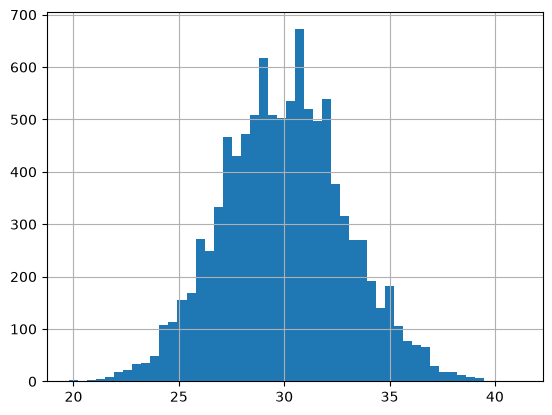

In [12]:
df.fuel_efficiency_mpg.hist(bins=50)
plt.show()

In [13]:
print(df.isnull().sum())
print(df.horsepower.median())

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64
254.0


In [15]:
def split_data(seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
    df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)
    return df_train, df_val, df_test

def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X) + r * np.eye(X.shape[1])
    w = np.linalg.inv(XTX).dot(X.T).dot(y)
    return w[0], w[1:]

def rmse(y, y_pred):
    return np.sqrt(((y - y_pred) ** 2).mean())

def prepare_X(df, fill_value):
    return df[base].fillna(fill_value).values

In [16]:
df_train, df_val, df_test = split_data(42)
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values

mean_hp = df_train.horsepower.mean()   # training set only!

for name, fill in [('zero', 0), ('mean', mean_hp)]:
    w0, w = train_linear_regression_reg(prepare_X(df_train, fill), y_train)
    y_pred = w0 + prepare_X(df_val, fill).dot(w)
    print(name, round(rmse(y_val, y_pred), 3))

zero 2.205
mean 2.202


In [17]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(prepare_X(df_train, 0), y_train, r=r)
    y_pred = w0 + prepare_X(df_val, 0).dot(w)
    print(r, round(rmse(y_val, y_pred), 4))

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


In [18]:
scores = []
for seed in range(10):
    df_train, df_val, df_test = split_data(seed)
    w0, w = train_linear_regression_reg(prepare_X(df_train, 0), df_train.fuel_efficiency_mpg.values)
    y_pred = w0 + prepare_X(df_val, 0).dot(w)
    scores.append(rmse(df_val.fuel_efficiency_mpg.values, y_pred))

print(round(np.std(scores), 3))

0.029


In [19]:
df_train, df_val, df_test = split_data(9)
df_full = pd.concat([df_train, df_val]).reset_index(drop=True)

w0, w = train_linear_regression_reg(prepare_X(df_full, 0), df_full.fuel_efficiency_mpg.values, r=0.001)
y_pred = w0 + prepare_X(df_test, 0).dot(w)
print(rmse(df_test.fuel_efficiency_mpg.values, y_pred))

2.2358277471917636
